# Making the dataset and training the model

This file contains the code to make the dataset from depth tensor and the embeddings retrieved from the same tensors. But also one thing to keep track is 
error value of -1 for places where no depth values could be retriebed. They need to be filtered out and left out of the final training data. 

In [1]:
import argparse
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

In [2]:
from utils import getDevice

In [3]:
class EmbedDepthDataset(Dataset):
    """
    This class matched the YOLO embeddings from a file to depth retrieved
    for the same images and creates a dataset from them, that can be used to 
    train the final model.

    Args:
        embed_path: path to .pt embeddings (N,256)
        depths_path: path to .pt (N,)
    """

    def __init__(self, embed_path: str, depths_path: str):
        #opening the files
        embeds = torch.load(embed_path, weights_only=True).float()
        depths = torch.load(depths_path, weights_only=True).float()

        #filtering depths to only allow valid ones
        print(f"Removing {(depths==-1).sum()} invalid depths")
        mask = depths != -1
        embeds_masked = embeds[mask]
        depths_masked = depths[mask]   

        #saving results
        self.depths = depths_masked
        self.embeddings = embeds_masked

        assert len(self.embeddings)==len(self.depths), (
            f"The embeddings array is not the same length as the depths"
            f"EMBEDDINGS: {len(self.embeddings)}\nDEPTHS: {len(self.depths)}"
        )

    def __len__(self):
        return len(self.embeddings)
    
    def __getitem__(self, idx):
        return self.embeddings[idx], self.depths[idx]

In [4]:
class DistanceRegressor(nn.Module):
    """
    Model to predict based on YOLO embeddings the distance to a car. It takes in (256) embedding and 
    outputs a single distance value in meters.

    Architecture is similar to the paper:
    1. Linear(256,128) + ReLU
    2. Linear(128,64) + ReLU
    3. Linear(64,1) + Softplus (to ensure positive output)
    """

    def __init__(self, input_size: int = 256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 2048),
            nn.ReLU(),
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Linear(512, 1),
            nn.Softplus()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [5]:
EMBED_PATH = "../data/embeds_preds.pt"
DEPTHS_PATH = "../data/ransac_depth.pt"

dataset = EmbedDepthDataset(EMBED_PATH, DEPTHS_PATH)

Removing 4 invalid depths


In [6]:
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss
model = DistanceRegressor()

# Create the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, eps=1.0)

epochs = 500

In [7]:
losses = np.array([])


for epoch in range(epochs):
    avg_loss = np.array([])
    for embeds, depths in DataLoader(dataset, batch_size=32, shuffle=True):
        # Forward pass
        preds = model(embeds)
        loss = loss_fn(preds.squeeze(), depths)
        
        avg_loss = np.append(avg_loss,loss.item())

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    losses = np.append(losses, avg_loss.mean())
    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs}, Loss: {losses[epoch]:.4f}")

/home/tim/sidehustle/thesis/.venv/lib64/python3.12/site-packages/torch/autograd/graph.py:829: UserWarning: XPU device count is zero! (Triggered internally at /pytorch/c10/xpu/XPUFunctions.cpp:115.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 0/500, Loss: 17.5932
Epoch 10/500, Loss: 8.1616
Epoch 20/500, Loss: 7.5781
Epoch 30/500, Loss: 6.4329
Epoch 40/500, Loss: 5.5691
Epoch 50/500, Loss: 5.0104
Epoch 60/500, Loss: 4.8079
Epoch 70/500, Loss: 4.5927
Epoch 80/500, Loss: 4.4403
Epoch 90/500, Loss: 4.3081
Epoch 100/500, Loss: 4.1445
Epoch 110/500, Loss: 4.1368
Epoch 120/500, Loss: 3.9292
Epoch 130/500, Loss: 3.8755
Epoch 140/500, Loss: 3.8044
Epoch 150/500, Loss: 3.7492
Epoch 160/500, Loss: 3.6540
Epoch 170/500, Loss: 3.5694
Epoch 180/500, Loss: 3.5669
Epoch 190/500, Loss: 3.5034
Epoch 200/500, Loss: 3.4623
Epoch 210/500, Loss: 3.4696
Epoch 220/500, Loss: 3.4818
Epoch 230/500, Loss: 3.3840
Epoch 240/500, Loss: 3.3075
Epoch 250/500, Loss: 3.2804
Epoch 260/500, Loss: 3.2772
Epoch 270/500, Loss: 3.2369
Epoch 280/500, Loss: 3.2275
Epoch 290/500, Loss: 3.1760
Epoch 300/500, Loss: 3.0965
Epoch 310/500, Loss: 3.0723
Epoch 320/500, Loss: 3.0928
Epoch 330/500, Loss: 3.0930
Epoch 340/500, Loss: 3.1092
Epoch 350/500, Loss: 3.1388
Ep

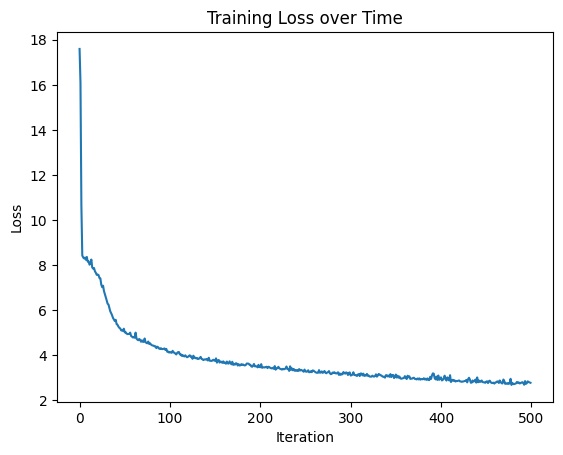

In [8]:
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss over Time")
plt.show()